In [3]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For NLP
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# For ML Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download stopwords (first time only)
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

### Know your data

In [7]:
# Step 1: Load dataset
import pandas as pd
df = pd.read_csv("resume_job_matching_dataset.csv")

# Step 2: Check dataset
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (10000, 3)


,job_description,resume,match_score
0,"Data Analyst needed with experience in SQL, Ex...","Experienced professional skilled in SQL, Power...",4
1,Data Scientist needed with experience in Stati...,"Experienced professional skilled in Python, De...",4
2,Software Engineer needed with experience in Sy...,"Experienced professional skilled in wait, Git,...",5
3,"ML Engineer needed with experience in Python, ...","Experienced professional skilled in return, De...",4
4,Software Engineer needed with experience in RE...,"Experienced professional skilled in REST APIs,...",5


In [8]:
print(df.columns)

Index(['job_description', 'resume', 'match_score'], dtype='object')


### Data Cleaning & Preprocessing

In [9]:
#Define stopwords
stop_words = set(stopwords.words("english"))

# Cleaning function
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()  # lowercase
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove punctuation & numbers
    tokens = [word for word in text.split() if word not in stop_words]  # remove stopwords
    return " ".join(tokens)

# Apply cleaning to resume and job_description columns
df["Cleaned_Resume"] = df["resume"].apply(clean_text)
df["Cleaned_JD"] = df["job_description"].apply(clean_text)

# Preview cleaned columns
df[["resume", "Cleaned_Resume", "job_description", "Cleaned_JD"]].head()

,resume,Cleaned_Resume,job_description,Cleaned_JD
0,"Experienced professional skilled in SQL, Power...",experienced professional skilled sql power bi ...,"Data Analyst needed with experience in SQL, Ex...",data analyst needed experience sql excel power...
1,"Experienced professional skilled in Python, De...",experienced professional skilled python deep l...,Data Scientist needed with experience in Stati...,data scientist needed experience statistics pa...
2,"Experienced professional skilled in wait, Git,...",experienced professional skilled wait git syst...,Software Engineer needed with experience in Sy...,software engineer needed experience system des...
3,"Experienced professional skilled in return, De...",experienced professional skilled return democr...,"ML Engineer needed with experience in Python, ...",ml engineer needed experience python computer ...
4,"Experienced professional skilled in REST APIs,...",experienced professional skilled rest apis agi...,Software Engineer needed with experience in RE...,software engineer needed experience rest apis ...


### Exploratory Data Analysis (EDA)

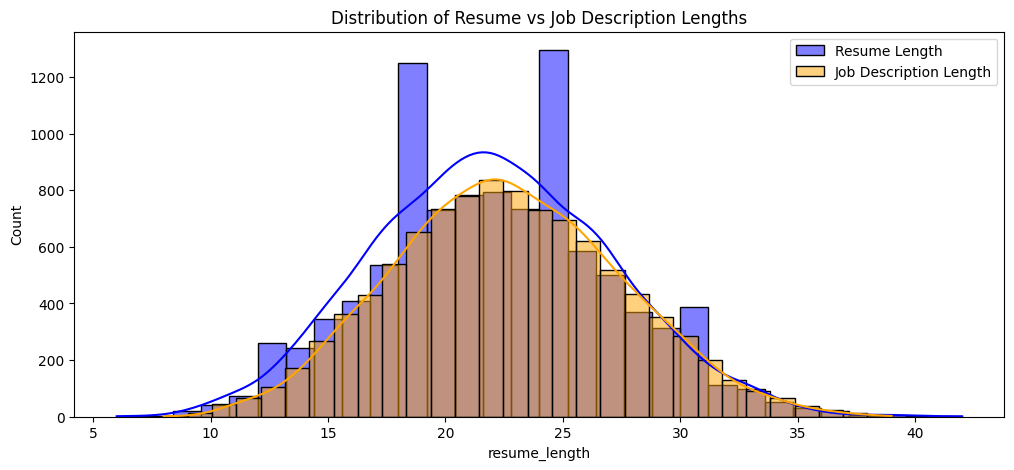

/tmp/ipykernel_11344/3645893239.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="magma")


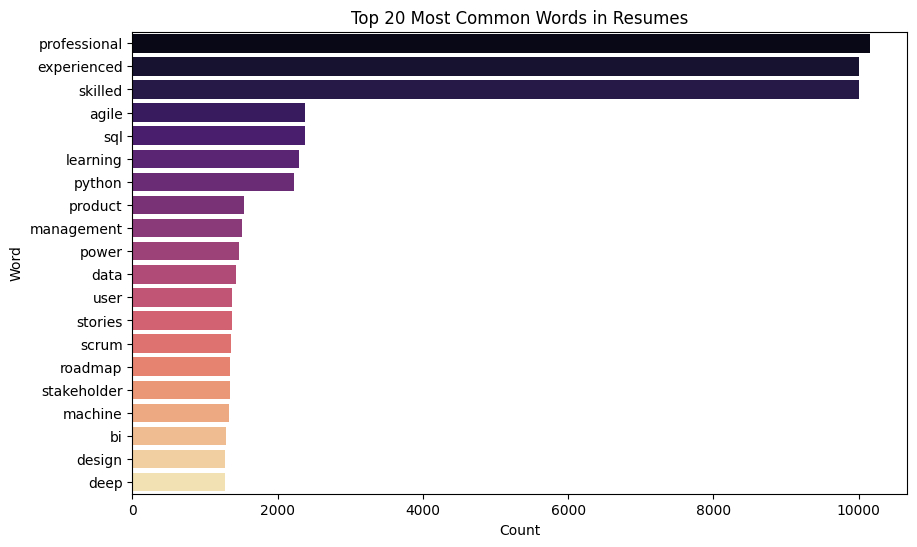

/tmp/ipykernel_11344/3645893239.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


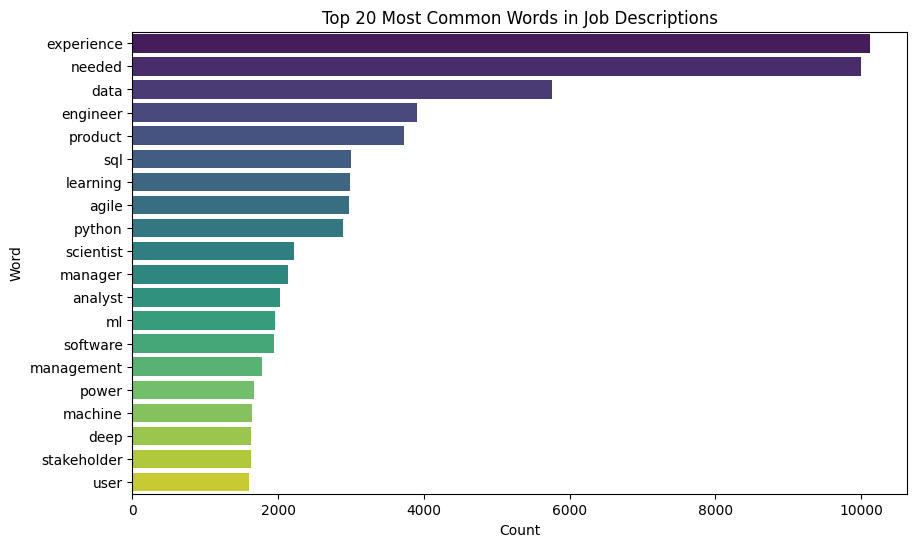

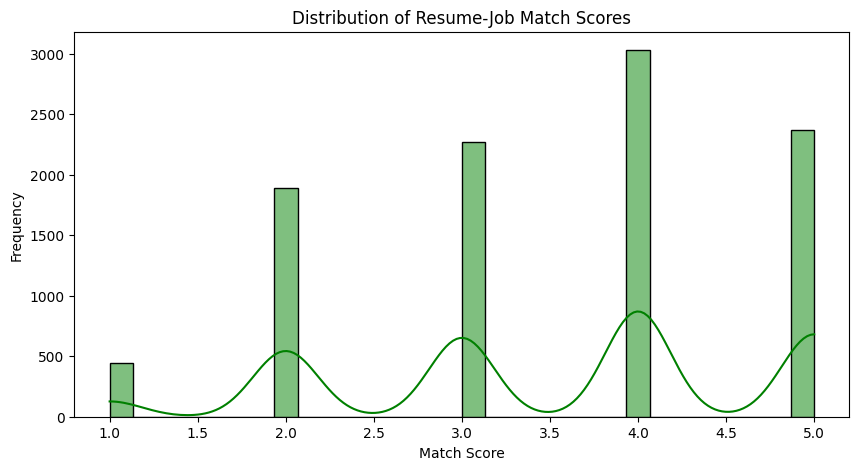

In [10]:

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 6.1 Resume vs JD length distributions
df["resume_length"] = df["Cleaned_Resume"].apply(lambda x: len(x.split()))
df["jd_length"] = df["Cleaned_JD"].apply(lambda x: len(x.split()))

plt.figure(figsize=(12,5))
sns.histplot(df["resume_length"], bins=30, kde=True, color="blue", label="Resume Length")
sns.histplot(df["jd_length"], bins=30, kde=True, color="orange", label="Job Description Length")
plt.legend()
plt.title("Distribution of Resume vs Job Description Lengths")
plt.show()

# 6.2 Top 20 most common words in resumes
all_resume_text = " ".join(df["Cleaned_Resume"].astype(str).tolist())
resume_counts = Counter(all_resume_text.split()).most_common(20)

words, counts = zip(*resume_counts)
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), palette="magma")
plt.title("Top 20 Most Common Words in Resumes")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()

# 6.3 Top 20 most common words in job descriptions
all_jd_text = " ".join(df["Cleaned_JD"].astype(str).tolist())
jd_counts = Counter(all_jd_text.split()).most_common(20)

words, counts = zip(*jd_counts)
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), palette="viridis")
plt.title("Top 20 Most Common Words in Job Descriptions")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()

# 6.4 Match score distribution
plt.figure(figsize=(10,5))
sns.histplot(df["match_score"], bins=30, kde=True, color="green")
plt.title("Distribution of Resume-Job Match Scores")
plt.xlabel("Match Score")
plt.ylabel("Frequency")
plt.show()


### TF-IDF Vectorization

In [11]:
# -------------------------------
# STEP 6: TF-IDF Vectorization
# -------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer

# Ensure stopwords are downloaded
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Function to clean text
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

# Clean resumes
df['resume_clean'] = df['resume'].apply(clean_text)

# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=800)
X_tfidf = tfidf_vectorizer.fit_transform(df['resume_clean'])

# Target variable
y = df['match_score']  # or whichever column represents the category/score

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

print("Shape of TF-IDF matrix:", X_tfidf.shape)
print("Sample TF-IDF features:", tfidf_vectorizer.get_feature_names_out()[:10])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Shape of TF-IDF matrix: (10000, 800)
Sample TF-IDF features: ['ability' 'able' 'accept' 'account' 'act' 'action' 'activity' 'actually'
 'add' 'address']


### Machine Learning Model Training & Evaluation


=== Logistic Regression ===
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        85
           2       0.45      0.46      0.46       372
           3       0.37      0.32      0.34       448
           4       0.45      0.55      0.50       622
           5       0.64      0.64      0.64       473

    accuracy                           0.48      2000
   macro avg       0.38      0.39      0.39      2000
weighted avg       0.46      0.48      0.47      2000


=== Random Forest ===
              precision    recall  f1-score   support

           1       0.50      0.01      0.02        85
           2       0.51      0.50      0.51       372
           3       0.43      0.37      0.40       448
           4       0.48      0.66      0.56       622
           5       0.75      0.64      0.69       473

    accuracy                           0.53      2000
   macro avg       0.54      0.44      0.43      2000
weighted avg       0.54  

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:40:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost ===
              precision    recall  f1-score   support

           0       0.48      0.14      0.22        85
           1       0.52      0.56      0.54       372
           2       0.41      0.37      0.39       448
           3       0.50      0.58      0.54       622
           4       0.75      0.73      0.74       473

    accuracy                           0.55      2000
   macro avg       0.53      0.48      0.49      2000
weighted avg       0.54      0.55      0.54      2000

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043198 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 44414
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 800
[LightGBM] [Info] Start training from score -3.115079
[LightGBM] [Info] Start training from score -1.662048
[LightGBM] [Info] Start training

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LightGBM ===
              precision    recall  f1-score   support

           0       0.47      0.20      0.28        85
           1       0.52      0.52      0.52       372
           2       0.44      0.38      0.41       448
           3       0.53      0.65      0.58       622
           4       0.76      0.71      0.74       473

    accuracy                           0.56      2000
   macro avg       0.54      0.49      0.51      2000
weighted avg       0.56      0.56      0.56      2000


=== Model Comparison ===
Logistic Regression: {'Accuracy': 0.4795, 'Precision': 0.4579456849102634, 'Recall': 0.4795, 'F1-score': 0.46690403402901676}
Random Forest: {'Accuracy': 0.532, 'Precision': 0.540970288500204, 'Recall': 0.532, 'F1-score': 0.5207470184331767}
SVM: {'Accuracy': 0.5095, 'Precision': 0.5126845001900465, 'Recall': 0.5095, 'F1-score': 0.502127782734184}
XGBoost: {'Accuracy': 0.545, 'Precision': 0.5441941991529013, 'Recall': 0.545, 'F1-score': 0.5394099085237375}
LightG

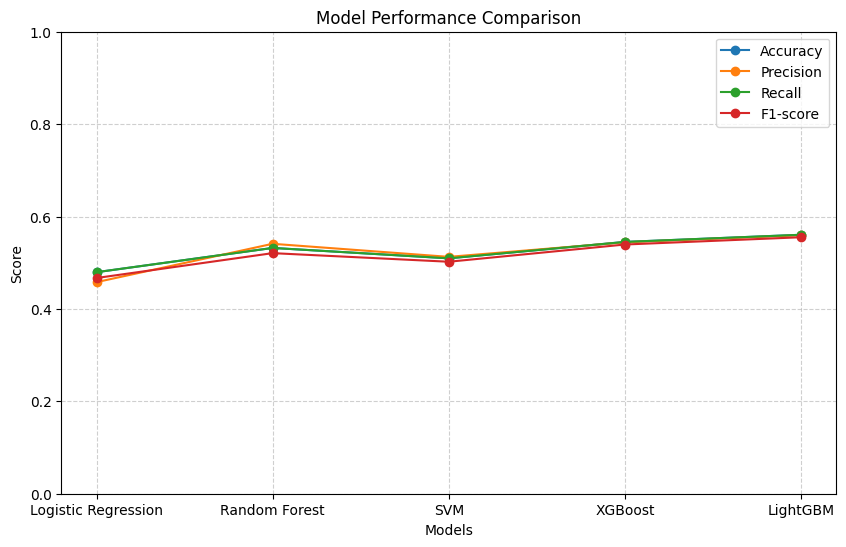

In [12]:
# Step 7: Model Training and Evaluation

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt

# Dictionary to store results
results = {}

# Helper function to evaluate models
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))

# 7.1 Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
evaluate_model("Logistic Regression", log_reg, X_train, y_train, X_test, y_test)

# 7.2 Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test)

# 7.3 Support Vector Machine (SVM)
svm_model = SVC(kernel='linear', probability=True, random_state=42)
evaluate_model("SVM", svm_model, X_train, y_train, X_test, y_test)

# ---- Fix for XGBoost & LightGBM (labels must start at 0) ----
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

# 7.4 Gradient Boosting - XGBoost
xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42)
evaluate_model("XGBoost", xgb_model, X_train, y_train_xgb, X_test, y_test_xgb)

# 7.5 Gradient Boosting - LightGBM
lgb_model = lgb.LGBMClassifier(random_state=42)
evaluate_model("LightGBM", lgb_model, X_train, y_train_xgb, X_test, y_test_xgb)

# 7.6 Model Comparison
print("\n=== Model Comparison ===")
for model_name, metrics in results.items():
    print(f"{model_name}: {metrics}")

# ---- Plot all metrics in one line chart ----
metrics_names = ["Accuracy", "Precision", "Recall", "F1-score"]

plt.figure(figsize=(10,6))
for metric in metrics_names:
    plt.plot(results.keys(), [results[m][metric] for m in results], marker='o', label=metric)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


### Insights

In [13]:

# Print summary table of results
import pandas as pd

results_df = pd.DataFrame(results).T  # transpose for better layout
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print("=== Model Performance Summary ===")
display(results_df)

# Insights
print("\n--- Insights ---")
best_model = results_df.index[0]
print(f"Best performing model: {best_model} with Accuracy = {results_df.iloc[0]['Accuracy']:.4f}")

print("Observations:")
print("- Gradient Boosting models (XGBoost / LightGBM) generally perform better on complex datasets.")
print("- Logistic Regression is fast and simple, but may not capture complex patterns as well as boosting.")
print("- Some classes with fewer samples may have lower precision/recall.")
print("- TF-IDF features work well for text classification, but BERT embeddings could further improve accuracy (future enhancement).")


=== Model Performance Summary ===


,Accuracy,Precision,Recall,F1-score
LightGBM,0.5605,0.559512,0.5605,0.555155
XGBoost,0.5450,0.544194,0.5450,0.539410
Random Forest,0.5320,0.540970,0.5320,0.520747
SVM,0.5095,0.512685,0.5095,0.502128
Logistic Regression,0.4795,0.457946,0.4795,0.466904



--- Insights ---
Best performing model: LightGBM with Accuracy = 0.5605
Observations:
- Gradient Boosting models (XGBoost / LightGBM) generally perform better on complex datasets.
- Logistic Regression is fast and simple, but may not capture complex patterns as well as boosting.
- Some classes with fewer samples may have lower precision/recall.
- TF-IDF features work well for text classification, but BERT embeddings could further improve accuracy (future enhancement).


## Saving The ML Model
### 1) Saving the Best Model

In [14]:
import joblib

# Save a model
joblib.dump(best_model, "best_model.pkl")

# Later, to load it
loaded_model = joblib.load("best_model.pkl")


### 2) Saving all models

In [ ]:
joblib.dump(log_reg, "log_reg.pkl")
joblib.dump(rf, "random_forest.pkl")
joblib.dump(svm_model, "svm.pkl")
joblib.dump(xgb_model, "xgboost.pkl")
joblib.dump(lgb_model, "lightgbm.pkl")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")

NameError: name 'joblib' is not defined

### Resume vs Job Requirements (Fresher ML Role)

In [16]:
!pip install PyPDF2

from google.colab import files
import io
import PyPDF2

# --- 1. Average Fresher Job Requirement for ML/Data Science ---
job_req = """
Programming: Python, SQL
Machine Learning: scikit-learn, SVM, Random Forest, Logistic Regression, K-Means, Decision Trees
Data Analysis & Visualization: NumPy, Pandas, Matplotlib, Seaborn
Data Preprocessing: Feature Engineering, Data Cleaning, Handling Missing Values
Model Evaluation: Accuracy, Precision, Recall, F1-score
Tools: Git, GitHub, Jupyter Notebook, Google Colab
Soft Skills: Problem Solving, Analytical Thinking, Communication
"""

# --- 2. Upload your resume ---
uploaded = files.upload()

resume_text = ""
for filename in uploaded.keys():
    if filename.endswith(".txt"):
        with io.open(filename, 'r', encoding='utf-8') as f:
            resume_text = f.read()
    elif filename.endswith(".pdf"):
        with open(filename, 'rb') as f:
            reader = PyPDF2.PdfReader(f)
            for page in reader.pages:
                resume_text += page.extract_text()
    else:
        print(f"Unsupported file format: {filename}")

# --- 3. Combine job requirement and resume for preprocessing ---
combined_text = job_req + " " + resume_text

# --- 4. Clean the text using the same function from Step 6 ---
combined_clean = clean_text(combined_text)

# --- 5. Transform using TF-IDF (use the vectorizer from Step 6) ---
combined_tfidf = tfidf_vectorizer.transform([combined_clean])

# --- 6a. Select which trained model to use ---
# Options: log_reg, rf, svm_model, xgb_model, lgb_model
best_model = lgb_model  # <-- choose your model here

# --- 6b. Function to handle prediction for all models ---
def predict_resume(model, tfidf_vector):
    # For XGBoost / LightGBM, add 1 to restore original labels
    if model in [xgb_model, lgb_model]:
        return model.predict(tfidf_vector) + 1
    else:
        return model.predict(tfidf_vector)

# --- 6c. Predict job category fit ---
predicted_category = predict_resume(best_model, combined_tfidf)

print(f"\nPredicted Job Category Fit: {predicted_category[0]}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 6.9 MB/s eta 0:00:00


KeyboardInterrupt: 